<br>

<hr>

<br>

## 05.04. 디자인 vs. 모델 기반 식별
- 회귀분석 또는 IPW 중 언제 어떤 방법을 사용해야 하는가?

    **이 선택은 모델 기반 (Model Based) 식별과 디자인 기반 (Design Based)식별에 관한 문제**

<br>

#### 모델 기반 식별 (Model Based Identification)
- **이 방식의 주인공은 결과 $Y$)**
- **핵심 아이디어 : 변수 $X$들을 가지고 결과 $Y$를 완벽하게 예측하는 공식을 만들 수 있다면, 처치를 안 받은 사람이 처치를 받았을 때 어떤 결과가 나왔을지도 예측할 수 있다**

    $\rightarrow$ **회귀분석 ($Y = f(T, X)$) 모델링**

- **목표 : 데이터에 없는 잠재적 결과 (Counterfactual)을 모델로 계산하여 채워넣는 것이 목표**

- 단점 : 만약 내가 세운 모델 자체가 실제와 거리가 멀다면, 결과는 완전히 틀리게 됨

<br>

#### 디자인 기반 식별 (Design Based Identification)
- **이 방식의 주인공은 처치 배정 ($T$)**
- **핵심 아이디어 : 누가 처치를 받았는지 그 과정 (매커니즘)만 정확히 안다면, 데이터를 재구성해서 무작위 실험(RCT)처럼 나들 수 있다**

    $\rightarrow$ **IPW (처치가 어떻게 배정되었는지(성향점수)를 모델링하고, 그 역수를 곱해 균형을 맞춤)**
- **목표 : 데이터의 처치 배정 디자인을 수정하여, 실험군과 대조군을 비교 가능한 상태로 만드는 것**
    - 결과$Y$가 얼마나 복잡하게 결정되는 지는 몰라도, 처치 $T$가 결정되는 과정만 잘 알면 인과 효과를 추론할 수 있음


<br>

- 회귀분석은 두 가지 관점에 모두 부합하는 방법
    - 모델 기반 관점 : 회귀분석을 통해 $Y$ 값을 '예측' (가장 일반적인 관점)
    - 디자인 기반 관점 (직교화) : 회구분석은 공변량 $X$의 영향을 제거(통제)하여 처치 $T$와 결과 $Y$ 사이의 순수한 관계만 남기는 과정 (=직교화)
        - 처치 배정의 불균형을 상쇄한다는 점에서 디자인 기반의 성격도 가짐

<br>

- **디자인 기반 식별과 모델 기반 식별 중 하나를 선택하려면 어떤 유형의 가정이 더 편한지에 대한 2가지 질문**
1. 처치는 어떻게 배정되었는지 잘 이해하고 있는가?
2. 잠재적 결과 모델을 올바르게 지정하는 더 좋은 방법이 있는가?


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import graphviz as gr
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
style.use("ggplot")
import statsmodels.formula.api as smf
import matplotlib
from cycler import cycler

color=['0.2', '0.6', '1.0']
default_cycler = (cycler(color=color))
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']


plt.rc('axes', prop_cycle=default_cycler)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/management_training.csv")
df.head()

,departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
0,76,1,0.277359,6,4,2,4,0.614261,0.224077,843
1,76,1,-0.449646,4,8,2,4,0.069636,0.224077,843
2,76,1,0.769703,6,4,2,4,0.866918,0.224077,843
3,76,1,-0.121763,6,4,2,4,0.029071,0.224077,843
4,76,1,1.526147,6,4,1,4,0.589857,0.224077,843


<br>

<hr>

<br>

## 05.05. 이중 강건 추정
- 디자인 기반 식별과, 모델 기반 식별 중 선택에 대한 확신이 없다면, 두 가지를 모두 선택

    $\rightarrow$ **이중 강건 (Double Robust, DR)은 모델 기반과 디자인 기반 식별을 모두 결합하여, 적어도 둘 중 하나가 정확하기를 기대하는 방법**



In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from patsy import dmatrix
from joblib import Parallel, delayed
from toolz import partial

In [7]:

def doubly_robust(df, formula, T, Y):
    X = dmatrix(formula, df)
    
    ps_model = LogisticRegression(max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]
    
    m0 = LinearRegression().fit(X[df[T]==0, :], df.query(f"{T}==0")[Y])
    m1 = LinearRegression().fit(X[df[T]==1, :], df.query(f"{T}==1")[Y])
    
    m0_hat = m0.predict(X)
    m1_hat = m1.predict(X)

    return (
        np.mean(df[T]*(df[Y] - m1_hat)/ps + m1_hat) -
        np.mean((1-df[T])*(df[Y] - m0_hat)/(1-ps) + m0_hat)
    )

In [8]:
def bootstrap(data, est_fn, rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)
    
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(data.sample(frac=1, replace=True)) # 부트스트랩 표본
        for _ in range(rounds)
    )
    
    return np.percentile(stats, pcts)

In [9]:
formula = """tenure + last_engagement_score + department_score + C(n_of_reports) + C(gender) + C(role)"""
T = "intervention"
Y = "engagement_score"

print("DR ATE:", doubly_robust(df, formula, T, Y))

est_fn = partial(doubly_robust, formula=formula, T=T, Y=Y)
print("95% CI", bootstrap(df, est_fn))

DR ATE: 0.2710696036739052
95% CI [0.22985697 0.30521352]


### 5.5.1 처치 모델링이 쉬운 경우


In [10]:
np.random.seed(123)

n = 10000
x = np.random.beta(1,1, n).round(2)*2
e = 1/(1+np.exp(-(1+1.5*x)))
t = np.random.binomial(1, e)

y1 = 1
y0 = 1 - 1*x**3
y = t*(y1) + (1-t)*y0 + np.random.normal(0, 1, n)

df_easy_t = pd.DataFrame(dict(y=y, x=x, t=t))

print("True ATE:", np.mean(y1-y0))

True ATE: 2.0056243152


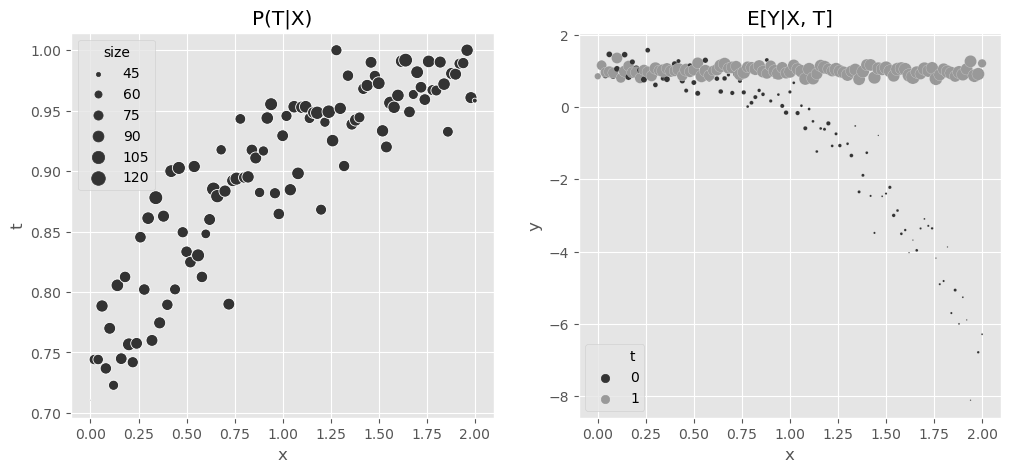

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=(df_easy_t
                      .assign(size=1)
                      .groupby(["x"])
                      .agg({"size":"sum", "t":"mean"})
                      .reset_index()),
                x="x", y="t", sizes=(1, 100), size="size", ax=ax1);
ax1.set_title("P(T|X)")

sns.scatterplot(data=(df_easy_t
                      .assign(size=1)
                      .groupby(["x", "t"])
                      .agg({"size":"sum", "y":"mean"})
                      .reset_index()),
                x="x", y="y", hue="t", sizes=(1, 100), size="size", ax=ax2)

ax2.set_title("E[Y|X, T]")

h,l = ax2.get_legend_handles_labels()
plt.legend(h[0:3],l[0:3])


In [12]:
m0 = smf.ols("y~x", data=df_easy_t.query("t==0")).fit()
m1 = smf.ols("y~x", data=df_easy_t.query("t==1")).fit()
regr_ate = (m1.predict(df_easy_t) - m0.predict(df_easy_t)).mean()

print("Regression ATE:", regr_ate)

Regression ATE: 1.7866783968330227


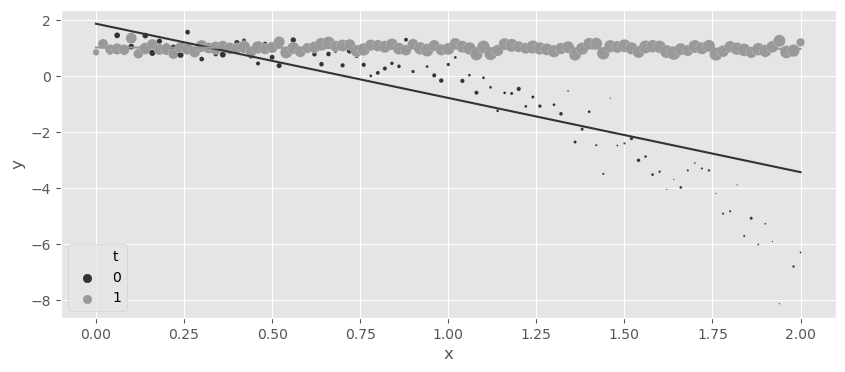

In [13]:
regr = smf.ols("y~x*t", data=df_easy_t).fit()

plt.figure(figsize=(10,4))

sns.scatterplot(data=(df_easy_t
                      .assign(count=1)
                      .groupby(["x", "t"])
                      .agg({"count":"sum", "y":"mean"})
                      .reset_index()),
                x="x", y="y", hue="t", sizes=(1, 100), size="count");

g = sns.lineplot(data=(df_easy_t
                   .assign(pred=regr.fittedvalues)
                   .groupby(["x", "t"])
                   .mean()
                   .reset_index()),
             x="x", y="pred", hue="t", sizes=(1, 100))

h,l = g.get_legend_handles_labels()
plt.legend(h[0:3],l[0:3])



In [14]:
m = smf.ols("y~t*(x + np.power(x, 3))", data=df_easy_t).fit()
regr_ate = (m.predict(df_easy_t.assign(t=1))
            - m.predict(df_easy_t.assign(t=0))).mean()

print("Regression ATE:", regr_ate)

Regression ATE: 1.9970999747189861


In [16]:
def est_ate_with_ps(df, ps_formula, T, Y):
    
    X = dmatrix(ps_formula, df)
    ps_model = LogisticRegression(max_iter=1000).fit(X, df[T])
    ps = ps_model.predict_proba(X)[:, 1]
    
    return np.mean((df[T]-ps) / (ps*(1-ps)) * df[Y]) 

In [17]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("Propensity Score ATE:", est_fn(df_easy_t))
print("95% CI", bootstrap(df_easy_t, est_fn))

Propensity Score ATE: 1.991089318939473
95% CI [1.80305132 2.21627653]


In [18]:
est_fn = partial(doubly_robust, formula="x", T="t", Y="y")
print("DR ATE:", est_fn(df_easy_t))
print("95% CI", bootstrap(df_easy_t, est_fn))

DR ATE: 1.99861467745835
95% CI [1.8693554  2.14273047]


### 5.5.2 결과 모델링이 쉬운 경우


In [19]:
np.random.seed(123)

n = 10000
x = np.random.beta(1,1, n).round(2)*2
e = 1/(1+np.exp(-(2*x - x**3)))
t = np.random.binomial(1, e)

y1 = x
y0 = y1 + 1 # ate of -1
y = t*(y1) + (1-t)*y0 + np.random.normal(0, 1, n)

df_easy_y = pd.DataFrame(dict(y=y, x=x, t=t))

print("True ATE:", np.mean(y1-y0))

True ATE: -1.0


The same kind of plot from before can be used to show the complex functional form for $P(T|X)$ and the simplicity of $E[Y_t|X]$.

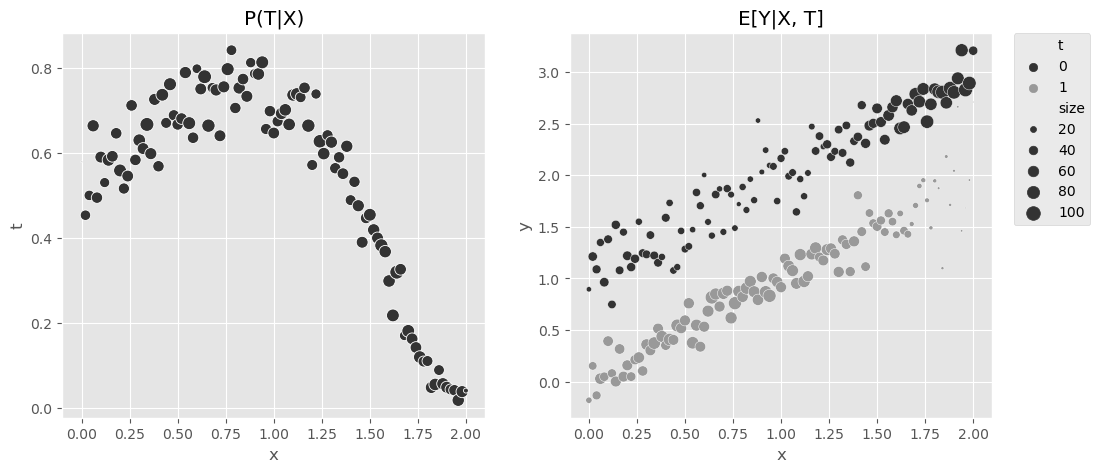

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=(df_easy_y
                      .assign(size=1)
                      .groupby(["x"])
                      .agg({"size":"sum", "t":"mean"})
                      .reset_index()),
                x="x", y="t", sizes=(1, 100), size="size", ax=ax1, legend=None);

sns.scatterplot(data=(df_easy_y
                      .assign(size=1)
                      .groupby(["x", "t"])
                      .agg({"size":"sum", "y":"mean"})
                      .reset_index()),
                x="x", y="y", hue="t", sizes=(1, 100), size="size", ax=ax2);

ax1.set_title("P(T|X)")
ax2.set_title("E[Y|X, T]")

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)


In [21]:
est_fn = partial(est_ate_with_ps, ps_formula="x", T="t", Y="y")
print("Propensity Score ATE:", est_fn(df_easy_y))
print("95% CI", bootstrap(df_easy_y, est_fn))

Propensity Score ATE: -1.104026419971194
95% CI [-1.14292551 -1.06558307]


In [22]:
m0 = smf.ols("y~x", data=df_easy_y.query("t==0")).fit()
m1 = smf.ols("y~x", data=df_easy_y.query("t==1")).fit()
regr_ate = (m1.predict(df_easy_y) - m0.predict(df_easy_y)).mean()

print("Regression ATE:", regr_ate)

Regression ATE: -1.0008783612504373


In [23]:
est_fn = partial(doubly_robust, formula="x", T="t", Y="y")
print("DR ATE:", est_fn(df_easy_y))
print("95% CI", bootstrap(df_easy_y, est_fn))

DR ATE: -1.0028376266139374
95% CI [-1.0415416  -0.96353624]


## 5.6 연속형 처치에서의 일반화 성향점수


In [24]:
df_cont_t = pd.read_csv("./data/interest_rate.csv")

df_cont_t.head()

,ml_1,ml_2,interest,duration
0,0.392938,0.326285,7.1,12.0
1,-0.427721,0.679573,5.6,17.0
2,-0.546297,0.647309,11.1,12.0
3,0.102630,-0.264776,7.2,18.0
4,0.438938,-0.648818,9.5,19.0


In [25]:
m_naive = smf.ols("duration ~ interest", data=df_cont_t).fit()
m_naive.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,14.5033,0.226,64.283,0.000,14.061,14.946
interest,0.3393,0.029,11.697,0.000,0.282,0.396


In [26]:
model_t = smf.ols("interest~ml_1+ml_2", data=df_cont_t).fit()

In [27]:
def conditional_density(x, mean, std):
    denom = std*np.sqrt(2*np.pi)
    num = np.exp(-((1/2)*((x-mean)/std)**2))
    return (num/denom).ravel()
    

gps = conditional_density(df_cont_t["interest"],
                          model_t.fittedvalues,
                          np.std(model_t.resid))
gps

array([0.1989118 , 0.14524168, 0.03338421, ..., 0.07339096, 0.19365006,
       0.15732008])

In [28]:
from scipy.stats import norm

gps = norm(loc=model_t.fittedvalues,
           scale=np.std(model_t.resid)).pdf(df_cont_t["interest"])
gps

array([0.1989118 , 0.14524168, 0.03338421, ..., 0.07339096, 0.19365006,
       0.15732008])

:::{admonition} Beyond the Normal
If the treatment follows another distribution other than the normal, you can use generalized linear models (`glm`) to fit it. For example, if $T$ was assigned according to a Poisson distribution, you could build the GPS weights with something like the following code
 
```python
import statsmodels.api as sm
from scipy.stats import poisson
 
mt = smf.glm("t~x1+x2",
             data=df, family=sm.families.Poisson()).fit()
 
gps = poisson(mu=m_pois.fittedvalues).pmf(df["t"])
 
w = 1/gps
```
 
:::
 
 
Using the inverse of the GPS as weights in a regression model can adjust for the bias. You can see that now you'll find a negative effect of interest on duration, which makes more business sense. 

In [29]:
final_model = smf.wls("duration~interest",
                      data=df_cont_t, weights=1/gps).fit()

final_model.params["interest"]

-0.6673977919925833

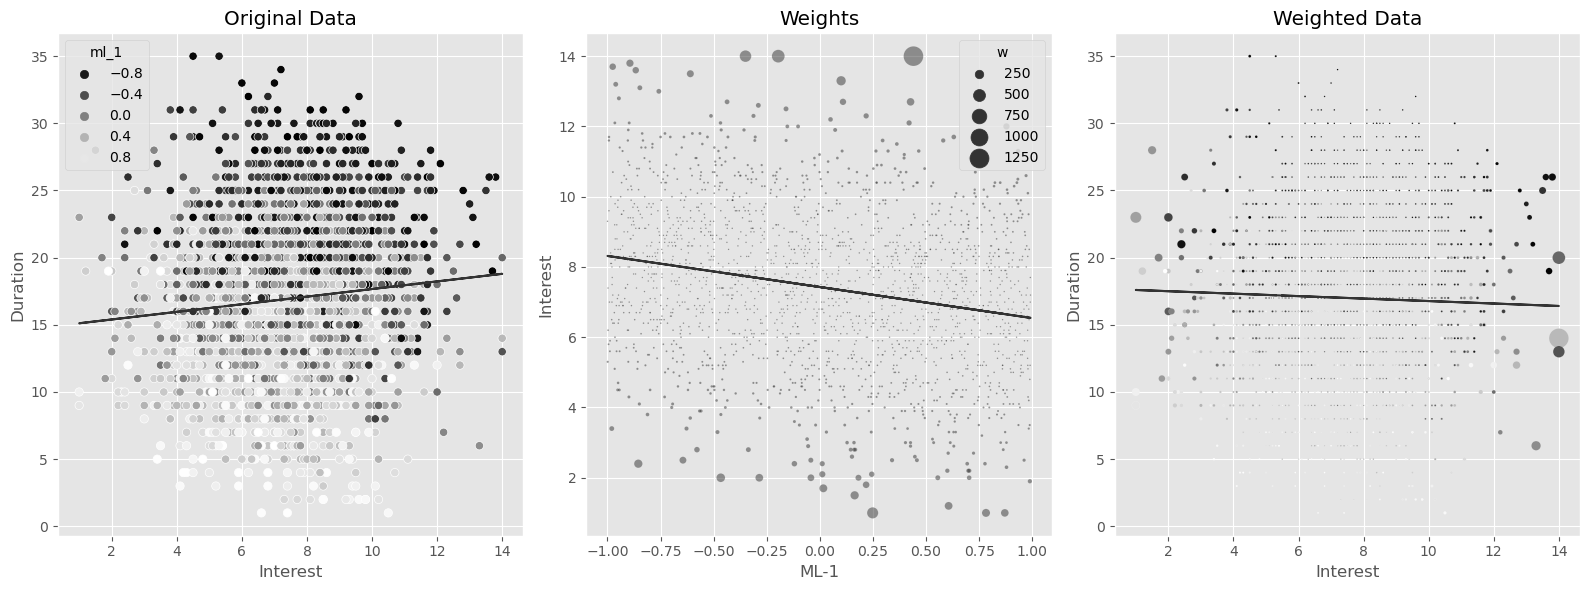

In [30]:
np.random.seed(1)
sample = df_cont_t.sample(2000)



model_ex = smf.ols("interest~ml_1", data=sample).fit()
gps_ex = norm(loc=model_ex.fittedvalues, scale=np.std(model_ex.resid)).pdf(sample["interest"])

w_ex = 1/gps_ex

m = smf.ols("duration~interest", data=sample).fit()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

sns.scatterplot(data=sample, x="interest", y="duration", alpha=1, ax=ax1, hue="ml_1", palette = 'gray')
ax1.plot(sample["interest"], m.fittedvalues)

ax1.set_ylabel("Duration")
ax1.set_xlabel("Interest")
ax1.set_title("Original Data");


sns.scatterplot(data=sample.assign(w=w_ex), x="ml_1", y="interest",size="w",
                sizes=(1,200), alpha=0.5, ax=ax2)
ax2.plot(sample["ml_1"], model_ex.fittedvalues)
ax2.set_ylabel("Interest")
ax2.set_xlabel("ML-1")
ax2.set_title("Weights")


m = smf.wls("duration~interest", data=sample, weights=w_ex).fit()

sns.scatterplot(data=sample.assign(w=w_ex), x="interest", y="duration",size="w",
                sizes=(1,200), alpha=1, ax=ax3, hue="ml_1", legend=None, palette = 'gray')
ax3.plot(sample["interest"], m.fittedvalues)
ax3.set_ylabel("Duration")
ax3.set_xlabel("Interest")
ax3.set_title("Weighted Data")

plt.tight_layout()



In [31]:
stabilizer = norm(
    loc=df_cont_t["interest"].mean(),
    scale=np.std(df_cont_t["interest"] - df_cont_t["interest"].mean())
).pdf(df_cont_t["interest"])

gipw =  stabilizer/gps

print("Original Sample Size:", len(df_cont_t))
print("Effective Stable Weights Sample Size:", sum(gipw))

Original Sample Size: 10000
Effective Stable Weights Sample Size: 9988.195951748608


Text(0.5, 1.0, 'Weighted Data')

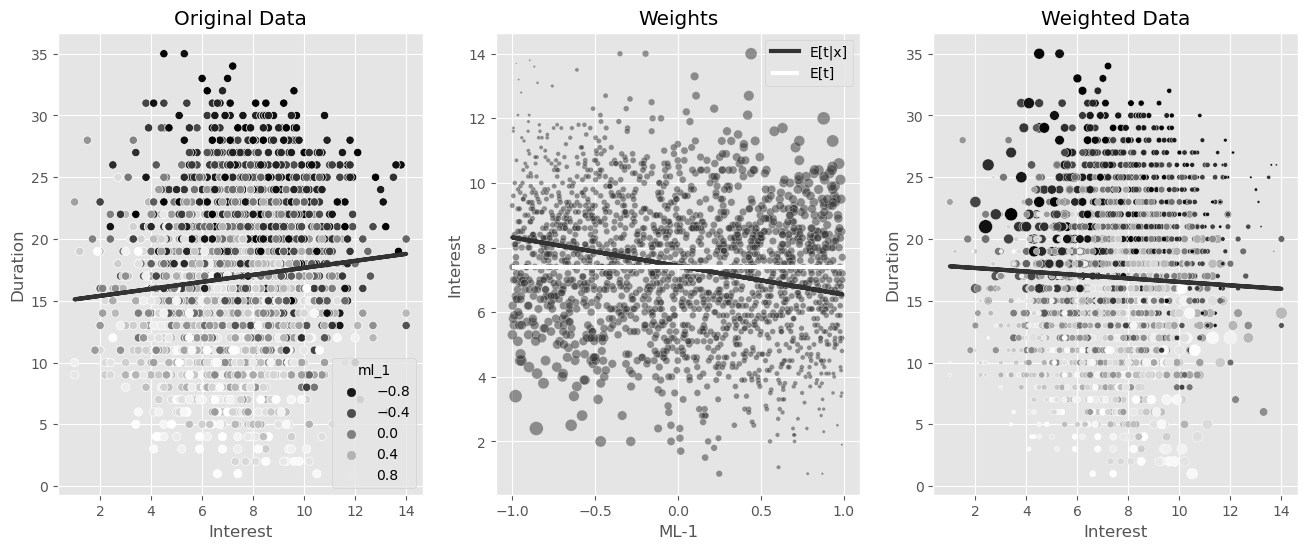

In [32]:
np.random.seed(1)
sample = df_cont_t.sample(2000)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

model_ex = smf.ols("interest~ml_1", data=sample).fit()
gps_ex = norm(loc=model_ex.fittedvalues, scale=np.std(model_ex.resid)).pdf(sample["interest"])
stabilizer_ex = norm(
    loc=sample["interest"].mean(),
    scale=np.std(sample["interest"] - sample["interest"].mean())
).pdf(sample["interest"])


w_ex = stabilizer_ex/gps_ex

m = smf.ols("duration~interest", data=sample).fit()

sns.scatterplot(data=sample, x="interest", y="duration", alpha=1, ax=ax1, hue="ml_1", palette = 'gray')
ax1.plot(sample["interest"], m.fittedvalues, lw=3)
ax1.set_ylabel("Duration")
ax1.set_xlabel("Interest")
ax1.set_title("Original Data");


sns.scatterplot(data=sample.assign(w=w_ex), x="ml_1", y="interest",size="w",
                sizes=(1,100), alpha=0.5, ax=ax2)

ax2.plot(sample["ml_1"], model_ex.fittedvalues, label="E[t|x]", lw=3)

ax2.hlines(sample["interest"].mean(), -1, 1, label="E[t]", color="C2", lw=3)
ax2.set_ylabel("Interest")
ax2.set_xlabel("ML-1")
ax2.set_title("Weights")

h,l = ax2.get_legend_handles_labels()
ax2.legend(h[5:],l[5:],)

m = smf.wls("duration~interest", data=sample, weights=w_ex).fit()

sns.scatterplot(data=sample.assign(w=w_ex), x="interest", y="duration",size="w",
                sizes=(1,100), alpha=1, ax=ax3, hue="ml_1", legend=None, palette = 'gray')
ax3.plot(sample["interest"], m.fittedvalues, lw=3)
ax3.set_ylabel("Duration")
ax3.set_xlabel("Interest")
ax3.set_title("Weighted Data")



In [33]:
final_model = smf.wls("duration ~ interest",
                      data=df_cont_t, weights=gipw).fit()

final_model.params["interest"]

-0.7787046278134035

In [34]:
def gps_normal_ate(df, formula, T, Y, stable=True):
    mt = smf.ols(f"{T}~"+formula, data=df).fit()
    gps = norm(loc=mt.fittedvalues, scale=np.std(mt.resid)).pdf(df[T])
    stabilizer = norm(
        loc=df[T].mean(),
        scale=np.std(df[T] - df[T].mean())
    ).pdf(df[T])
    
    if stable:
        return smf.wls(f"{Y}~{T}", data=df, weights=stabilizer/gps).fit().params[T]
    else:
        return smf.wls(f"{Y}~{T}", data=df, weights=1/gps).fit().params[T]

print("95% CI, non-stable: ", bootstrap(df_cont_t, partial(gps_normal_ate, formula="ml_1 + ml_2", T="interest", Y="duration", stable=False)))
print("95% CI, stable: ", bootstrap(df_cont_t, partial(gps_normal_ate, formula="ml_1 + ml_2", T="interest", Y="duration")))

95% CI, non-stable:  [-0.81074164 -0.52605933]
95% CI, stable:  [-0.85834311 -0.71001914]


## 5.7 요약


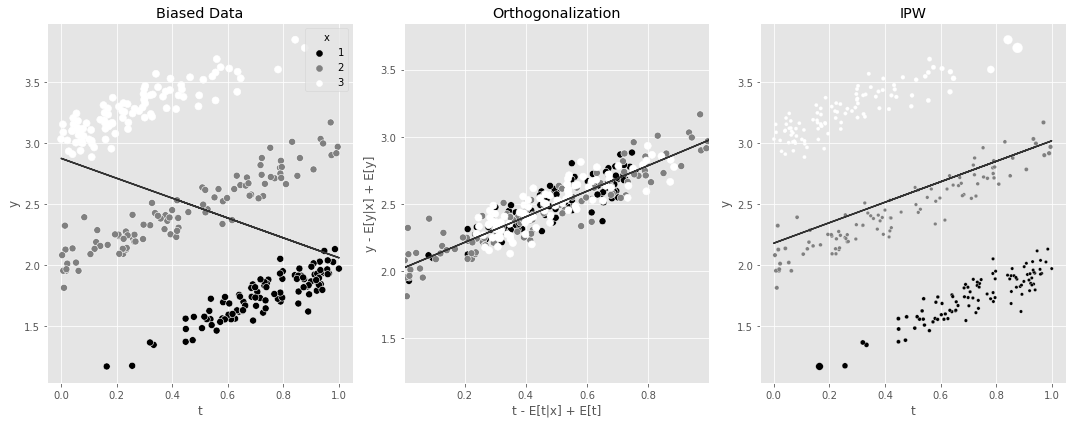

In [51]:
np.random.seed(1)

n=100

df1 = pd.DataFrame(dict(
    x=1,
    t=np.random.beta(2.5,1, n),
)).assign(y = lambda d: np.random.normal(d["x"]+d["t"], 0.1))

df2 = pd.DataFrame(dict(
    x=2,
    t=np.random.beta(1,1, n),
)).assign(y = lambda d: np.random.normal(d["x"]+d["t"], 0.1))

df3 = pd.DataFrame(dict(
    x=3,
    t=np.random.beta(1,2.5, n),
)).assign(y = lambda d: np.random.normal(d["x"]+d["t"], 0.1))


df_example = pd.concat([df1, df2, df3])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,6))

m = smf.ols("y~t", data=df_example).fit()
sns.scatterplot(data=df_example, x="t", y="y",  hue="x", s=50, ax=ax1, palette = 'gray')
ax1.plot(df_example["t"], m.fittedvalues)
ax1.set_title("Biased Data")

## Orthogonalization

mt = smf.ols("t~x", data=df_example).fit()
my = smf.ols("y~x", data=df_example).fit()

df_ex_res = df_example.assign(
    t_res = mt.resid + df_example["t"].mean(),
    y_res = my.resid + df_example["y"].mean()
)

m_final = smf.ols("y_res~t_res", data=df_ex_res).fit()
sns.scatterplot(data=df_ex_res, x="t_res", y="y_res",  hue="x", s=50, ax=ax2, legend=None, palette = 'gray')
ax2.plot(df_ex_res["t_res"], m_final.fittedvalues)

ax2.set_ylim(df_example["y"].min(), df_example["y"].max())
ax2.set_xlim(df_example["t"].min(), df_example["t"].max())

ax2.set_ylabel("y - E[y|x] + E[y]")
ax2.set_xlabel("t - E[t|x] + E[t]")
ax2.set_title("Orthogonalization")


## IPW
gps_example = norm(loc=mt.fittedvalues, scale=np.std(mt.resid)).pdf(df_example["t"])
stabilizer_example = norm(
    loc=df_example["t"].mean(),
    scale=np.std(df_example["t"] - df_example["t"].mean())
).pdf(df_example["t"])


w_example = stabilizer_example/gps_example
mw = smf.wls("y~t", data=df_example, weights=w_example).fit()


sns.scatterplot(data=df_example.assign(w=w_example), x="t", y="y",  hue="x", ax=ax3, size="w",
                legend=None, sizes=(11,100), palette = 'gray')
ax3.plot(df_example["t"], mw.fittedvalues)
ax3.set_title("IPW")

plt.tight_layout()
